## Установка PySpark

In [ ]:
!apt-get update

Get:1 http://security.ubuntu.com/ubuntu jammy-security InRelease [129 kB]
Get:2 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ InRelease [3,632 B]
Hit:3 http://archive.ubuntu.com/ubuntu jammy InRelease
Get:4 https://developer.download.nvidia.com/compute/cuda/repos/ubuntu2204/x86_64  InRelease [1,581 B]
Get:5 http://archive.ubuntu.com/ubuntu jammy-updates InRelease [128 kB]
Get:6 https://r2u.stat.illinois.edu/ubuntu jammy InRelease [6,555 B]
Hit:7 https://ppa.launchpadcontent.net/deadsnakes/ppa/ubuntu jammy InRelease
Hit:8 https://ppa.launchpadcontent.net/graphics-drivers/ppa/ubuntu jammy InRelease
Hit:9 https://ppa.launchpadcontent.net/ubuntugis/ppa/ubuntu jammy InRelease
Get:10 http://archive.ubuntu.com/ubuntu jammy-backports InRelease [127 kB]
Get:11 https://developer.download.nvidia.com/compute/cuda/repos/ubuntu2204/x86_64  Packages [1,642 kB]
Get:12 https://r2u.stat.illinois.edu/ubuntu jammy/main all Packages [8,901 kB]
Get:13 http://security.ubuntu.com/ubuntu jammy-sec

In [ ]:
!apt-get install openjdk-8-jdk-headless -qq > /dev/null

In [ ]:
!wget -q https://archive.apache.org/dist/spark/spark-3.3.2/spark-3.3.2-bin-hadoop3.tgz

In [ ]:
!tar -xvf spark-3.3.2-bin-hadoop3.tgz

spark-3.3.2-bin-hadoop3/
spark-3.3.2-bin-hadoop3/LICENSE
spark-3.3.2-bin-hadoop3/NOTICE
spark-3.3.2-bin-hadoop3/R/
spark-3.3.2-bin-hadoop3/R/lib/
spark-3.3.2-bin-hadoop3/R/lib/SparkR/
spark-3.3.2-bin-hadoop3/R/lib/SparkR/DESCRIPTION
spark-3.3.2-bin-hadoop3/R/lib/SparkR/INDEX
spark-3.3.2-bin-hadoop3/R/lib/SparkR/Meta/
spark-3.3.2-bin-hadoop3/R/lib/SparkR/Meta/Rd.rds
spark-3.3.2-bin-hadoop3/R/lib/SparkR/Meta/features.rds
spark-3.3.2-bin-hadoop3/R/lib/SparkR/Meta/hsearch.rds
spark-3.3.2-bin-hadoop3/R/lib/SparkR/Meta/links.rds
spark-3.3.2-bin-hadoop3/R/lib/SparkR/Meta/nsInfo.rds
spark-3.3.2-bin-hadoop3/R/lib/SparkR/Meta/package.rds
spark-3.3.2-bin-hadoop3/R/lib/SparkR/Meta/vignette.rds
spark-3.3.2-bin-hadoop3/R/lib/SparkR/NAMESPACE
spark-3.3.2-bin-hadoop3/R/lib/SparkR/R/
spark-3.3.2-bin-hadoop3/R/lib/SparkR/R/SparkR
spark-3.3.2-bin-hadoop3/R/lib/SparkR/R/SparkR.rdb
spark-3.3.2-bin-hadoop3/R/lib/SparkR/R/SparkR.rdx
spark-3.3.2-bin-hadoop3/R/lib/SparkR/doc/
spark-3.3.2-bin-hadoop3/R/lib/Spar

In [ ]:
!pip install -q findspark

In [ ]:
import os
os.environ["JAVA_HOME"] = "/usr/lib/jvm/java-8-openjdk-amd64"
os.environ["SPARK_HOME"] = "/content/spark-3.3.2-bin-hadoop3"

In [ ]:
import findspark
findspark.init()
from pyspark.sql import SparkSession

spark = SparkSession.builder.master("local[*]").getOrCreate()

## Загрузите данные при помощи spark.read.csv из приложенного файла

In [25]:
!wget https://gist.githubusercontent.com/netj/8836201/raw/iris.csv

--2025-05-02 10:18:08--  https://gist.githubusercontent.com/netj/8836201/raw/iris.csv
Resolving gist.githubusercontent.com (gist.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to gist.githubusercontent.com (gist.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 3975 (3.9K) [text/plain]
Saving to: ‘iris.csv’

iris.csv            100%[===================>]   3.88K  --.-KB/s    in 0s      

2025-05-02 10:18:08 (33.4 MB/s) - ‘iris.csv’ saved [3975/3975]



In [26]:
df=spark.read.csv('iris.csv',inferSchema=True, header=True)
df.show(5)

+------------+-----------+------------+-----------+-------+
|sepal.length|sepal.width|petal.length|petal.width|variety|
+------------+-----------+------------+-----------+-------+
|         5.1|        3.5|         1.4|        0.2| Setosa|
|         4.9|        3.0|         1.4|        0.2| Setosa|
|         4.7|        3.2|         1.3|        0.2| Setosa|
|         4.6|        3.1|         1.5|        0.2| Setosa|
|         5.0|        3.6|         1.4|        0.2| Setosa|
+------------+-----------+------------+-----------+-------+
only showing top 5 rows



## Воспользуйтесь командами groupBy, max, min и avg, чтобы вывести максимальное минимальное и среднее значние каждого из аттрбутов цветка ('sepal_length','sepal_width','petal_length','petal_width')

In [28]:
from pyspark.sql.functions import max

df.select(
    max("`sepal.length`").alias("max_sepal_length"),
    max("`sepal.width`").alias("max_sepal_width"),
    max("`petal.length`").alias("max_petal_length"),
    max("`petal.width`").alias("max_petal_width")
).show()

+----------------+---------------+----------------+---------------+
|max_sepal_length|max_sepal_width|max_petal_length|max_petal_width|
+----------------+---------------+----------------+---------------+
|             7.9|            4.4|             6.9|            2.5|
+----------------+---------------+----------------+---------------+



In [29]:
from pyspark.sql.functions import min

df.select(
    min("`sepal.length`").alias("min_sepal_length"),
    min("`sepal.width`").alias("min_sepal_width"),
    min("`petal.length`").alias("min_petal_length"),
    min("`petal.width`").alias("min_petal_width")
).show()

+----------------+---------------+----------------+---------------+
|min_sepal_length|min_sepal_width|min_petal_length|min_petal_width|
+----------------+---------------+----------------+---------------+
|             4.3|            2.0|             1.0|            0.1|
+----------------+---------------+----------------+---------------+



In [30]:
from pyspark.sql.functions import avg

df.select(
    avg("`sepal.length`").alias("avg_sepal_length"),
    avg("`sepal.width`").alias("avg_sepal_width"),
    avg("`petal.length`").alias("avg_petal_length"),
    avg("`petal.width`").alias("avg_petal_width")
).show()

+-----------------+-----------------+------------------+-----------------+
| avg_sepal_length|  avg_sepal_width|  avg_petal_length|  avg_petal_width|
+-----------------+-----------------+------------------+-----------------+
|5.843333333333335|3.057333333333334|3.7580000000000027|1.199333333333334|
+-----------------+-----------------+------------------+-----------------+



In [31]:
import matplotlib.pyplot as plt

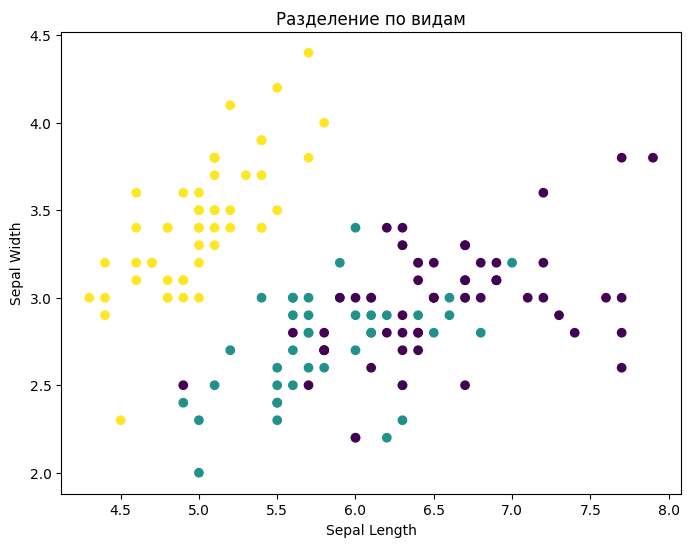

In [37]:
# Сначала собираем данные из нужных колонок
data = df.select("`sepal.length`", "`sepal.width`", "variety").collect()

# Преобразуем в NumPy
sepal_length = [row[0] for row in data]
sepal_width = [row[1] for row in data]
variety = [row[2] for row in data]

# Приводим variety к числам (для раскраски по цвету)
variety_map = {name: i for i, name in enumerate(set(variety))}
variety_num = [variety_map[v] for v in variety]

# Строим график
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))
plt.scatter(sepal_length, sepal_width, c=variety_num, cmap='viridis')
plt.xlabel("Sepal Length")
plt.ylabel("Sepal Width")
plt.title("Разделение по видам")
plt.show()


## Выведите по аналогии график petal_length и petal_width, так же раскрашенный по типам цветков

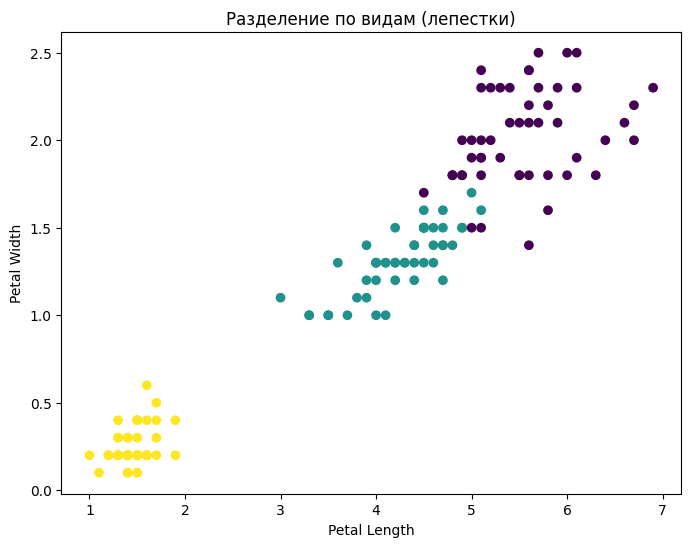

In [38]:
# Сначала собираем данные из нужных колонок
data = df.select("`petal.length`", "`petal.width`", "variety").collect()

# Преобразуем в списки
petal_length = [row[0] for row in data]
petal_width = [row[1] for row in data]
variety = [row[2] for row in data]

# Преобразуем типы цветков в числа
variety_map = {name: i for i, name in enumerate(set(variety))}
variety_num = [variety_map[v] for v in variety]

# Строим график
plt.figure(figsize=(8, 6))
plt.scatter(petal_length, petal_width, c=variety_num, cmap='viridis')
plt.xlabel("Petal Length")
plt.ylabel("Petal Width")
plt.title("Разделение по видам (лепестки)")
plt.show()

## Посмотрите внимательно на получившийся график и сформируйте правило вида ЕСЛИ ЗНАЧЕНИЕ ПАРАМЕТРА A < ЗНАЧЕНИЕ, ТО IRIS ОТНОСИТСЯ К КЛАССУ SETOSA - ИНАЧЕ К КАКОМУ-ТО ДРУГОМУ (НАЗОВЕМ, ЕГО НАПРИМЕР UNKNOWN)
## При помощи команд withColumn, when, otherwise создайте в датафрейме новую колонку с таким предсказанием

In [41]:
from pyspark.sql.functions import when

In [43]:
df = df.withColumn(
    "predicted_class",
    when(df["`petal.length`"] < 2, "Setosa").otherwise("Unknown")
)
df.select("`petal.length`", "variety", "predicted_class").show(10)

+------------+-------+---------------+
|petal.length|variety|predicted_class|
+------------+-------+---------------+
|         1.4| Setosa|         Setosa|
|         1.4| Setosa|         Setosa|
|         1.3| Setosa|         Setosa|
|         1.5| Setosa|         Setosa|
|         1.4| Setosa|         Setosa|
|         1.7| Setosa|         Setosa|
|         1.4| Setosa|         Setosa|
|         1.5| Setosa|         Setosa|
|         1.4| Setosa|         Setosa|
|         1.5| Setosa|         Setosa|
+------------+-------+---------------+
only showing top 10 rows



## Проверьте качество своего предсказания
Для этого:
1. Подсчитайте количество строк, где Вы предсказали класс Setosa и правильный класс был так же Setosa
2. Подсчитайте количество строк, где Вы предскзали класс Setosa, а правильный класс был какой-то другой (воспользуйтесь оператором "не равно" - !=)

In [44]:
# Предсказали Setosa и угадали
correct_predictions = df.filter((df["predicted_class"] == "Setosa") & (df["variety"] == "Setosa")).count()

In [45]:
# Предсказали Setosa, но ошиблись
wrong_predictions = df.filter((df["predicted_class"] == "Setosa") & (df["variety"] != "Setosa")).count()

In [46]:
print("✅ Верно предсказано Setosa:", correct_predictions)
print("❌ Неверно предсказано Setosa:", wrong_predictions)

✅ Верно предсказано Setosa: 50
❌ Неверно предсказано Setosa: 0
